# CSE 25 - Introduction to Artificial Intelligence
## Week 4 Thursday: Review

**Learning Objectives:**

Here's what we've worked towards in this course so far:
- Identify examples of artificial intelligence appearing in everyday situations described in the article and class discussion, including less obvious cases.
- Explain, using examples from NY Times article and discussion, why it can be unclear what should or should not be considered AI.
- Articulate what makes a system intelligent using examples discussed in class.
- Explain the Five Big Ideas of AI (**Perception**, **Representation**, **Learning**, **Interaction**, **Societal Impact**) and apply them to multiple systems, noting where they do and do not apply.
- Identify major areas where AI techniques are commonly used (such as vision, language, recommendation systems, robotics, and multimodal systems) and explain what kinds of problems they address.
- Interpret CSE course titles and descriptions to make informed, high-level connections between AI ideas, application areas, and the curriculum.
- Describe Turing’s "Imitation Game” and its connection to artificial intelligence.
- Identify and describe the key stages of a machine learning pipeline: **Problem formulation**, **Data/Experience collection**, **Data processing**, **Training**, **Evaluation**, **Deployment**.
- Explain why machine learning systems are iterative.
- Classify learning systems as **supervised**, **unsupervised**, or **reinforcement** learning based on the type of data or feedback used.
- Explain how a simple linear model makes predictions using parameters.
- Compute and interpret pointwise and total error.
- Describe brute-force parameter search and when it is feasible.
- Explain why error minimization is central to learning systems.
- Describe several ways of measuring error of a model and compare their properties.
- Interpret error as a function of a model parameter.
- Explain how changing a parameter affects error.
- Describe brute-force search as a way to find better parameters.
- Explain, at a high level, how slope (rate of change) tells us which direction to adjust a parameter.
- Describe the difference between local and global optima.
- Connect these ideas to the motivation behind gradient descent.
- Define simple and multiple linear regression as fitting a hyperplane to predict target values from input features.
- Distinguish between **regression** and **classification** problems  
- Explain how a **perceptron** uses a weighted sum and bias to make decisions  
- Describe how the perceptron updates its parameters when it makes a mistake  
- Explain what the words **features**, **labels**, **bias**, **decision boundary**, and **epoch** mean
- Define linear separability and give examples of data sets that are or aren't linearly separable
- Distinguish between local and global minima and explain how an algorithm might avoid local minima.
- Use a trained linear model to make predictions on new, unseen data  
- Compute **accuracy** from predictions and labels (or class)
- Use a **confusion matrix** to compute **precision**, **recall**, and **F1** score
- Connect metrics of classification to goals for applying ML systems
- Describe why the perceptron update rule works for binary settings.
- Define perceptron loss.
- Explain the purpose of **train / validation / test** splits
- Define and describe **generalization**, **overfitting**, and **underfitting**
- Interpret a **training** curve
- Interpret a **learning** curve

Today we'll review some of these key concepts and explore new examples.

Instructions

Use your copy of this notebook on Datahub and complete it during class. Work through the cells below **in order**. You may discuss with your neighbors, but make sure you understand each step yourself.


SUBMISSION:
When finished, download it as a PDF and upload it to Gradescope under `In-Class – Week 4 Thursday` to receive credit. To download it as a PDF, on DataHub go to `File -> Save and Export Notebook As -> PDF`.

## Regression
For input $x$, the model with parameters weight $w$ and bias $b$ predicts the value
$$wx + b$$

### Using a linear model to predict values, and calculating error in the prediction

In [ ]:
def get_predictions_v2(input_values, w, b):
    '''
    input_values: list of input values
    w: weight (slope)
    b: bias (intercept)

    Complete the function that calculates the predicted output values using the weight and bias. 
    Return a list of predicted values.
    '''
    # Initialize an empty list (predicted_values) to store predicted values
    predicted_values = []
    
    # Calculate predicted values for each input value by multiplying with conversion factor and append it to predicted_values list
    for input_value in input_values:
        predicted_values.append(input_value * w + b)
    
    # Return the list of predicted values
    return predicted_values

def get_pointwise_error(actual_values, predicted_values):
    '''
    actual_values: list of actual kilometer values
    predicted_values: list of predicted kilometer values

    Complete the function that calculates the error (actual minus predicted) between predicted and actual values for each value and returns a list of these errors.
    '''    
    # Calculate and return the list of errors for each point
    return [actual - predicted for actual, predicted in zip(actual_values, predicted_values)]

def get_pointwise_absolute_error(actual_values, predicted_values):
    '''
    actual_values: list of actual output values
    predicted_values: list of predicted output values

    Complete the function that calculates the absolute error between predicted and actual values for each value and returns a list of these absolute errors.
    '''
    # Calculate and return the list of absolute errors for each point
    return [abs(actual - predicted) for actual, predicted in zip(actual_values, predicted_values)]

def get_total_absolute_error(actual_values, predicted_values):
    '''
    errors: list of errors for each data point
    Complete the function that calculates the total error by summing the values of the individual errors. Return the total error.
    '''
    return sum(get_pointwise_absolute_error(actual_values,predicted_values))

def get_mean_absolute_error(actual_values, predicted_values):
    '''
    actual_values: list of actual output values
    predicted_values: list of predicted output values

    Complete the function that calculates the Mean Absolute Error (MAE) between predicted and actual values.
    Return the MAE.
    '''
    # Calculate the list of absolute errors for each point and return its mean
    return  (sum(get_pointwise_absolute_error(actual_values, predicted_values)))*1.0 / len(actual_values)

def get_mean_squared_error(actual_values, predicted_values):
    '''
    actual_values: list of actual output values
    predicted_values: list of predicted output values

    Complete the function that calculates the Mean Squared Error (MSE) between predicted and actual values.
    Return the MSE.
    '''
    # Initialize list to store squared errors
    sq_errors = []
    # Loop through each value and accumulate the squared error
    for act, pred in zip(actual_values, predicted_values):
        sq_errors.append((act-pred)**2)
    # Calculate the mean squared error (MSE) by dividing the total squared error by the number of values
    return sum(sq_errors)*1.0/len(sq_errors)


### Using brute-force search to train model for regression

In [16]:
import matplotlib.pyplot as plt

def brute_force_search(X, y, error_function, lower_w = 0.0, upper_w = 1.0, lower_b = -60, upper_b = 40, step_size_w = 0.1, step_size_b = 0.01 ):
    best_weight = None # Initialize best weight
    best_bias = None # initalize best bias
    lowest_error = float('inf') # Initialize to a very high value

    weights = [] # To store weights tried
    bias = [] # To store bias tried
    error_list = [] # To store errors for each weight

    # Try weights from lower_w to upper_w in n_steps steps
    # Try bias from lower_b to upper_b in n_steps steps
    w = lower_w
    b = lower_b

    while w <= upper_w:
        while b <= upper_b:
            predicted = get_predictions_v2(X, w, b)
            error = error_function(y, predicted)
            error_list.append(error) # for the plot
            weights.append(w) # for the plot
            bias.append(b)
            if error < lowest_error:
                lowest_error = error
                best_weight = w
                best_bias = b
            b += step_size_b
        b = lower_b
        w += step_size_w

    print(f'Best weight (conversion factor): {best_weight:.4f}')
    print(f'Best bias: {best_bias:.4f}')
    print(f'Lowest error: {lowest_error:.2f}')

    return best_weight, best_bias, lowest_error

In [ ]:
# Example data set for learning conversion from degrees Fahrenheit to degrees Celsius

fahrenheit = [32, 50, 68, 86, 104] # x-axis values (INPUT DATA)
celsius = [0, 10, 20, 30, 40] # y-axis values (OUTPUT DATA)

print("Brute force search with total absolute error")
brute_force_search(fahrenheit, celsius, get_total_absolute_error)

print("\nBrute force search with mean absolute error")
brute_force_search(fahrenheit, celsius, get_mean_absolute_error)

print("\nBrute force search with mean squared error")
brute_force_search(fahrenheit, celsius, get_mean_squared_error)

Brute force search with total absolute error
Best weight (conversion factor): 0.6000
Best bias: -20.8000
Lowest error: 4.80

Brute force search with mean absolute error
Best weight (conversion factor): 0.6000
Best bias: -20.8000
Lowest error: 0.96

Brute force search with mean squared error
Best weight (conversion factor): 0.6000
Best bias: -20.8000
Lowest error: 1.28


(0.6, -20.80000000000382, 1.28)

Q: Why do all three error functions give the same best model parameters?

`YOUR ANSWER HERE`

Q: Why is the lowest error different for each of the error functions even though the model parameters are the same?

`YOUR ANSWER HERE`


### Using gradient descent to train model for regression

In [18]:
def get_gradients_w_b(error_function, input_values, actual_values, w, b, epsilon=1e-6):
    """
    Approximates the partial derivatives of the error with respect to w and b
    using finite differences.

    Returns:
        (grad_w, grad_b)
    """

    # Compute predictions using the current parameters (w, b)
    predicted = get_predictions_v2(input_values,w,b)

    # Compute the error at (w, b)
    error = error_function(actual_values,predicted)

    # --- Partial derivative with respect to w ---
    # Compute predictions at (w + epsilon, b)
    predicted_w = get_predictions_v2(input_values, w+epsilon, b)
    # Compute the error at (w + epsilon, b)
    error_w = error_function(actual_values,predicted_w)
    # Approximate the partial derivative with respect to w
    grad_w = (error_w - error)/epsilon

    # --- Partial derivative with respect to b ---
    # Compute predictions at (w, b + epsilon)
    predicted_b = get_predictions_v2(input_values,w,b+epsilon)
    # Compute the error at (w, b + epsilon)
    error_b = error_function(actual_values,predicted_b)
    # Approximate the partial derivative with respect to b
    grad_b = (error_b-error)/epsilon

    return grad_w, grad_b

def gradient_descent_w_b(X, y, initial_w = 1, initial_b = -60,  learning_rate = 0.0001, num_steps = 250000 ):

    # Initialize parameters
    w = initial_w
    b = initial_b
    # Initialize history lists
    grad_weights = []
    grad_biases = []
    grad_errors = []

    for step in range(num_steps):
        predicted = get_predictions_v2(X, w, b)
        error = get_mean_squared_error(y, predicted)
        grad_weights.append(w)
        grad_biases.append(b)
        grad_errors.append(error)
        grad_w, grad_b = get_gradients_w_b(get_mean_squared_error, X, y, w, b)
        w = w - learning_rate * grad_w
        b = b - learning_rate * grad_b
        if step % 25000 == 0:
            print(f"Step {step}: w = {w:.4f}, b = {b:.4f}, error = {error:.4f}")

    print(f"Best weight (w) found: {w:.4f}")
    print(f"Best bias (b) found: {b:.4f}")
    print(f"Mean squared error at best parameters: {grad_errors[-1]:.4f}")

    return w, b, grad_errors[-1]

In [21]:
print("Gradient descent to train model for degrees Fahrenheit to degrees Celsius")
gradient_descent_w_b(fahrenheit, celsius)


Gradient descent to train model for degrees Fahrenheit to degrees Celsius
Step 0: w = 1.1056, b = -59.9976, error = 272.0000
Step 25000: w = 0.8501, b = -40.6155, error = 64.1100
Step 50000: w = 0.7149, b = -30.1312, error = 18.7583
Step 75000: w = 0.6417, b = -24.4599, error = 5.4885
Step 100000: w = 0.6022, b = -21.3922, error = 1.6058
Step 125000: w = 0.5808, b = -19.7328, error = 0.4698
Step 150000: w = 0.5692, b = -18.8352, error = 0.1374
Step 175000: w = 0.5629, b = -18.3496, error = 0.0402
Step 200000: w = 0.5595, b = -18.0870, error = 0.0118
Step 225000: w = 0.5577, b = -17.9449, error = 0.0034
Best weight (w) found: 0.5567
Best bias (b) found: -17.8681
Mean squared error at best parameters: 0.0010


(0.5567195662611255, -17.86805949685861, 0.0010018925991128508)

Q: Which performed better, brute-force search or gradient descent?

`YOUR ANSWER HERE`

Q: Is this a fair comparison?

`YOUR ANSWER HERE`

## Binary classification
For input $x = [x1, \ldots xn]$, the perceptron with parameters weights $w$ and bias $b$ predicts the label $+1$ if the score 
$$z = \sum_{i=1}^n w_ix_i + b$$
is greater than or equal to $0$, and predicts the label $-1$ if $z < 0$.

### Using a perceptron model to predict labels, and calculating error in the prediction

In [22]:
def perceptron_predict(x, w, b):
    '''
    x: 2D input list [x1, x2]
    w: 2D weight list [w1, w2]
    b: bias term
    '''
    # Score = w_1*x_1 + w_2*x_2 + b
    score = w[0]*x[0]+ w[1]*x[1] +b
    # Return +1 if score >= 0 else -1
    if score >= 0:
        return 1
    else:
        return -1

def compute_metrics(y_true, y_pred):
    '''
    Compute accuracy, precision, and recall for binary labels in {-1, +1}.

    Treats +1 as the positive class.

    Returns a tuple (accuracy, precision, recall).
    Precision and recall are set to 0.0 when the denominator would be zero
    (i.e. the model never predicts positive, or there are no true positives).
    '''
    tp = sum(1 for t, p in zip(y_true, y_pred) if t ==  1 and p ==  1)
    tn = sum(1 for t, p in zip(y_true, y_pred) if t == -1 and p ==  1)
    fp = sum(1 for t, p in zip(y_true, y_pred) if t == -1 and p ==  1)
    fn = sum(1 for t, p in zip(y_true, y_pred) if t ==  1 and p == -1)

    accuracy  = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2.0 * (precision * recall)/(precision + recall) if (precision + recall) > 0 else 0.0

    return accuracy, precision, recall, f1

def perceptron_loss(y, z):
    '''
    Computes the perceptron loss for a given example to a model
    '''
    return max(0, -y*z)

In [ ]:
import random

def perceptron_train_eval_with_history(X, y, num_epochs=10,X_test=None, y_test=None):
    '''
    Train a perceptron and record loss, accuracy, precision, and recall
    after every individual data point is processed (across all epochs).

    X: list of [x1, x2] feature pairs
    y: list of labels in {-1, +1}
    num_epochs: number of full passes over the data
    X_test, y_test: optional test sets for calculating test accuracty

    Returns
    w, b : final weights and bias
    history : dictionary with keys 'loss', 'accuracy', 'precision', 'recall',
              each a list of length (num_epochs * len(X)). Also has a key 'test_accuracy' (one value per epoch) if X_test is provided.
    '''
    w = [0.0, 0.0]
    b = 0.0

    history = {'loss': [], 'accuracy': [], 'precision': [], 'recall': [], 'test_accuracy': []}

    rng = random.Random(42)

    for epoch in range(num_epochs):
        # Shuffle a new order each epoch
        combined = list(zip(X, y))
        rng.shuffle(combined)

        for x, y_true in combined:
            # Calculate perceptron score and apply update rule
            score  = w[0] * x[0] + w[1] * x[1] + b
            y_pred = 1 if score >= 0 else -1

            if y_pred != y_true:
                w[0] += y_true * x[0]
                w[1] += y_true * x[1]
                b    += y_true

            # Calculate current model predictions for all training data
            all_preds = perceptron_predict(X, w, b)

            # Total perceptron loss = sum of max(0, -y*z) across all points
            total_loss = sum(
                max(0.0, -yt * (w[0]*xt[0] + w[1]*xt[1] + b))
                for xt, yt in zip(X, y)
            )

            acc, prec, rec = compute_metrics(y, all_preds)

            history['loss'].append(total_loss)
            history['accuracy'].append(acc)
            history['precision'].append(prec)
            history['recall'].append(rec)

        # Record test accuracy once per epoch
        if X_test is not None and y_test is not None:
            test_preds = perceptron_predict_all(X_test, w, b)
            test_acc, _, _ = compute_metrics(y_test, test_preds)
            history['test_accuracy'].append(test_acc)

        if history['accuracy'][-1] == 1.0: break

    return w, b, history

In [ ]:
# With stratification
from typing import List, Sequence, Tuple 

def train_test_split_v2(
    X: Sequence[Sequence[float]],
    y: Sequence[int],
    test_ratio: float = 0.2,
    seed: int = 0,
    shuffle: bool = True,
) -> Tuple[List[List[float]], List[List[float]], List[int], List[int]]:
    '''
    Split data set with stratification: preserves class proportions in each split.

    X: list of input features
    y: list of target labels
    test_ratio: fraction of the data to put in the test set. Must be between 0 and 1. Default is 0.2 (20%).
    seed: Random seed used for shuffling, so results are reproducible. Default is 0.
    shuffle: If True, randomly shuffle the data before splitting.
            If False, take the first (1 - test_ratio) fraction for training and the rest for testing. Default is True.
    '''
    # Create a local instance random number generator, in case shuffle is True.
    rng = random.Random(seed)
    # Group indices by class label
    labels = list(set(y))
    class_indices = {label: [i for i, v in enumerate(y) if v == label] for label in labels}

    train_indices = []
    test_indices  = []

    for label in labels:
        idxs = class_indices[label][:]
        if shuffle:
            rng.shuffle(idxs)
        n_test = max(1, round(len(idxs) * test_ratio))
        test_indices  += idxs[:n_test]
        train_indices += idxs[n_test:]

    if shuffle:
        rng.shuffle(train_indices)
        rng.shuffle(test_indices)

    X_list = [list(row) for row in X]
    y_list = [int(v)    for v in y]

    return (
        [X_list[i] for i in train_indices],
        [X_list[i] for i in test_indices],
        [y_list[i] for i in train_indices],
        [y_list[i] for i in test_indices],
    )

##### Precision vs Recall in Real-World Scenarios

Recall the definitions:
**`Accuracy`**: Of all the examples the model predicted, how many predictions were correct?
$$
\text{Accuracy}=\frac{TP+TN}{TP+TN+FP+FN}
$$


**`Precision`**: Of all the examples the model *predicted* as positive, how many were actually positive?

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

**`Recall`**: Of all the examples that are *actually* positive, how many did the model correctly identify? Recall is also known as *True Positive Rate (TPR)*.

$$
\text{Recall} = \frac{TP}{TP + FN}
$$


**Discuss and answer the following**

Q. Look at the formulas for precision and recall above and answer the following in plain English:

- If **precision** is high, what does that tell us about the model's positive predictions?
- If **recall** is high, what does that tell us about the model's ability to find actual positives?

`YOUR ANSWER HERE`

Below are two example situations. Read each one and think about which type of mistake matters more.


**Example 1**

A medical screening system checks images for signs of a serious disease. Missing a real case could delay treatment, but extra follow-up tests are acceptable.

- Would you prioritize **precision** or **recall** here?  
- Which mistake is worse: a false positive or a false negative?  
- Briefly explain your reasoning.

`YOUR ANSWER HERE`


**Example 2**

An automated system flags students for academic misconduct.  A false accusation could unfairly penalize a student and cause stress.

- Would you prioritize **precision** or **recall** here?  
- Which mistake is worse: a false positive or a false negative?  
- Briefly explain your reasoning.

`YOUR ANSWER HERE`


##### Your Turn

Come up with **two real-world scenarios**:

- One where you would prefer **high precision**.
- One where you would prefer **high recall**.

For each scenario, describe:

- What counts as a positive prediction?
- What is a false positive?
- What is a false negative?
- Which mistake matters more, and why?

`YOUR ANSWER HERE`


We have covered three foundational linear models so far:

- **Linear Regression**: Uses the identity activation function and is trained with Mean Squared Error (MSE) loss. This model is suitable for regression tasks where the output is continuous.

- **Perceptron**: Uses the sign (or step) activation function and is trained using the perceptron update rule, which can be interpreted as minimizing the perceptron loss. This model is designed for binary classification with hard decision boundaries.

- **Logistic Regression**: Uses the sigmoid activation function and is trained with Binary Cross-Entropy (BCE) loss. This model outputs probabilities for binary classification.

  *(Note: We did not formally use this term earlier, but the sigmoid + BCE single-layer model is commonly known as Logistic Regression.)*

Although these models differ in activation functions and loss functions, they all share the same underlying structure: a single linear decision boundary.

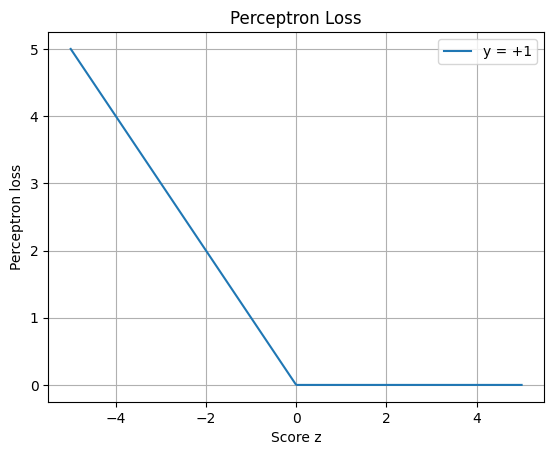

In [1]:
import numpy as np
# Import the matplotlib library for plotting
import matplotlib.pyplot as plt

# Range of scores
z = np.linspace(-5, 5, 400)

# Perceptron loss
loss_y_pos = np.maximum(0, -z)   # y = +1
loss_y_neg = np.maximum(0, z)    # y = -1

plt.figure()
plt.plot(z, loss_y_pos, label="y = +1")

# Uncomment the next line to see the loss function for when y = -1
#plt.plot(z, loss_y_neg, label="y = -1")

plt.xlabel("Score z")
plt.ylabel("Perceptron loss")
plt.title("Perceptron Loss")
plt.grid(True)
plt.legend()
plt.show()

In [2]:
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
import numpy as np  # Used only for fast grid rendering
import math

# Data using standard Python lists (labels in {-1, +1})
X_toy = [[1.5, 4.0], [1.0, 2.0], [2.0, 1.0], [3.0, 5.0], [4.0, 2.0], [0.0, 0.0], [1.5, -0.5]]
y_toy = [1, 1, -1, 1, -1, -1, -1]

def combined_perceptron_plot(w1=1.0, w2=1.0, b=-2.0):
    '''
    Display two views of data set and perceptron model performance.

    w1,w2: model weights (default: 1.0)
    b: model bias (default: -2.0)
    '''
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # LEFT: 1D Step View (sign)
    z_axis = [z * 0.1 for z in range(-100, 101)]
    ax1.plot(z_axis, [1 if z >= 0 else -1 for z in z_axis],
             color='green', drawstyle='steps-mid', label="sign(z)")
    ax1.axvline(x=0, color='black', linestyle='--', alpha=0.5)
    
    total_loss = 0  # Initialize loss counter
    
    for i in range(len(X_toy)):
        x1, x2 = X_toy[i]
        y = y_toy[i]
        z_score = w1 * x1 + w2 * x2 + b
        pred = 1 if z_score >= 0 else -1
        
        loss = max(0.0, -y * z_score)  # Perceptron loss
        total_loss += loss
        
        color, m = ('blue', 'x') if y == 1 else ('red', 'o')
        if y == 1:
            ax1.scatter(z_score, pred, color=color, marker=m, s=100, linewidths=2, zorder=5)
        else:
            ax1.scatter(z_score, pred, color=color, marker=m, s=80, edgecolors='k', zorder=5)
            
    # Update title with the calculated loss
    ax1.set_title(f"Perceptron: Score vs Prediction\nTotal Perceptron Loss: {total_loss:.2f}")
    ax1.set_xlabel("Score (z)")
    ax1.set_ylim(-1.1, 1.1)
    ax1.set_yticks([-1, 1])

    # RIGHT: 2D Feature Space (Speedy Rendering)
    xx, yy = np.meshgrid(np.linspace(-1, 5, 100), np.linspace(-1, 6, 100))
    zz = w1 * xx + w2 * yy + b

    # Binary background: everything <0 is blue, everything >0 is red
    ax2.contourf(xx, yy, zz, levels=[-1e9, 0, 1e9], colors=['red','blue'], alpha=0.2)

    if w2 != 0:
        x_line = np.array([-1, 5])
        y_line = -(w1 * x_line + b) / w2
        ax2.plot(x_line, y_line, "k-", linewidth=2)

    for i in range(len(X_toy)):
        x1, x2 = X_toy[i]
        y = y_toy[i]
        if y == 1:
            ax2.scatter(x1, x2, color='blue', marker='x', s=100, linewidths=2)
        else:
            ax2.scatter(x1, x2, color='red', marker='o', s=80, edgecolors='k')
        # label each point with its coordinates
        ax2.annotate(
        f'({x1}, {x2})',          # text to display
        xy=(x1, x2),              # point the text refers to
        xytext=(5, 5),            # offset in points from the marker (right and up)
        textcoords='offset points',
        fontsize=10,
        color='black',
        )

    ax2.set_xlim(-1, 5)
    ax2.set_ylim(-1, 6)
    ax2.set_title("2D View: Hard Decision Regions")
    plt.tight_layout()
    plt.show()

interact(combined_perceptron_plot,
         w1=(-5.0, 5.0, 0.1),
         w2=(-5.0, 5.0, 0.1),
         b=(-10.0, 10.0, 0.1))


interactive(children=(FloatSlider(value=1.0, description='w1', max=5.0, min=-5.0), FloatSlider(value=1.0, desc…

<function __main__.combined_perceptron_plot(w1=1.0, w2=1.0, b=-2.0)>

Q: Match the points on the left graph with the points on the right graph

`YOUR ANSWER HERE`

Q: For the default model parameters, what is the Total Perceptron Loss, as displayed on the graph?

`YOUR ANSWER HERE`

Q: Calculate this number directly from the definition:

$$\text{Total perceptron loss} = \sum_{data} -y\left( \sum_{i=1}^n w_i x_i + b \right)$$

`YOUR ANSWER HERE`


### Graphing training performance

For a binary prediction model that predicts labels +1 (positive) or -1 (negative), the confusion counts for a data set are 

- **TP**: number of true positive (true 1, predicted 1) examples
- **FP**: number of false positive (true -1, predicted 1) examples
- **FN**: number of false negative (true 1, predicted -1) examples
- **TN**: number of true negative (true -1, predicted -1) examples


**`Accuracy`**: Of all the examples the model predicted, how many predictions were correct?
$$
\text{Accuracy}=\frac{TP+TN}{TP+TN+FP+FN}
$$


**`Precision`**: Of all the examples the model *predicted* as positive, how many were actually positive?

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

**`Recall`**: Of all the examples that are *actually* positive, how many did the model correctly identify? Recall is also known as *True Positive Rate (TPR)*.

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

To see how training impacts these model metrics, we'll graph the performance of a model as the model parameters change during training.

In [3]:
import random

# Perceptron learning implementation from last time, somewhat reorganized

def perceptron_predict_all(X_list, w, b):
    '''
    Return a list of predictions (+1 or -1) for every point in X_list.
    '''
    return [1 if w[0]*x[0] + w[1]*x[1] + b >= 0 else -1 for x in X_list]

def compute_metrics(y_true, y_pred):
    '''
    Compute accuracy, precision, and recall for binary labels in {-1, +1}.

    Treats +1 as the positive class.

    Returns a tuple (accuracy, precision, recall).
    Precision and recall are set to 0.0 when the denominator would be zero
    (i.e. the model never predicts positive, or there are no true positives).
    '''
    tp = sum(1 for t, p in zip(y_true, y_pred) if t ==  1 and p ==  1)
    fp = sum(1 for t, p in zip(y_true, y_pred) if t == -1 and p ==  1)
    fn = sum(1 for t, p in zip(y_true, y_pred) if t ==  1 and p == -1)

    accuracy  = sum(1 for t, p in zip(y_true, y_pred) if t == p) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return accuracy, precision, recall

def perceptron_train_with_history(X, y, num_epochs=10):
    '''
    Train a perceptron and record loss, accuracy, precision, and recall
    after every individual data point is processed (across all epochs).

    X: list of [x1, x2] feature pairs
    y: list of labels in {-1, +1}
    num_epochs: number of full passes over the data

    Returns
    w, b : final weights and bias
    history : dictionary with keys 'loss', 'accuracy', 'precision', 'recall',
              each a list of length (num_epochs * len(X))
    '''
    w = [0.0, 0.0]
    b = 0.0

    history = {'loss': [], 'accuracy': [], 'precision': [], 'recall': []}

    rng = random.Random(42)

    for epoch in range(num_epochs):
        # Shuffle a new order each epoch
        combined = list(zip(X, y))
        rng.shuffle(combined)

        for x, y_true in combined:
            # Calculate perceptron score and apply update rule
            score  = w[0] * x[0] + w[1] * x[1] + b
            y_pred = 1 if score >= 0 else -1

            if y_pred != y_true:
                w[0] += y_true * x[0]
                w[1] += y_true * x[1]
                b    += y_true

            # Calculate current model predictions for all training data
            all_preds = perceptron_predict_all(X, w, b)

            # Total perceptron loss = sum of max(0, -y*z) across all points
            total_loss = sum(
                max(0.0, -yt * (w[0]*xt[0] + w[1]*xt[1] + b))
                for xt, yt in zip(X, y)
            )

            acc, prec, rec = compute_metrics(y, all_preds)

            history['loss'].append(total_loss)
            history['accuracy'].append(acc)
            history['precision'].append(prec)
            history['recall'].append(rec)

    return w, b, history

We will plot each of these metrics during a training run. Before we do, let's make some predictions.

Q: At what value do we expect each metric to settle? 

`YOUR ANSWER HERE`

Q: Does the above answer depend on the observation that the toy data set is **linearly separable**?

`YOUR ANSWER HERE`

Q: Do we expect each metric to rise, drop, or oscillate?

`YOUR ANSWER HERE`

Num points in training set is 7
Num steps in training process is 35
Num epochs run is  35


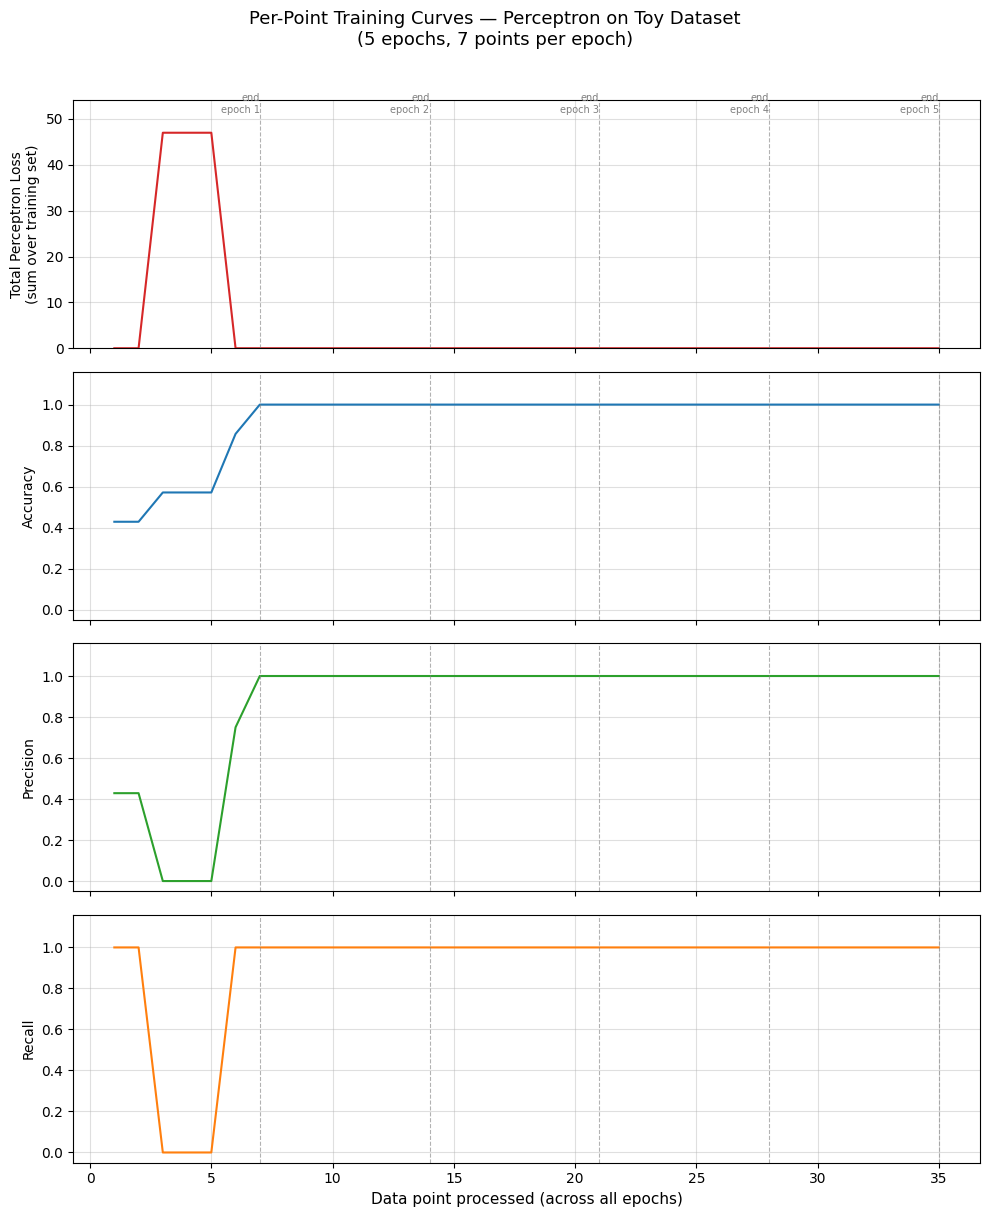

Final weights: w = [-2.5, 2.0], b = -1.0


In [ ]:
# Plot four training curves with different y axes: perceptron loss and accuracy and precision and recall after each point.

NUM_EPOCHS = 5

w_final, b_final, history = perceptron_train_with_history(
    X_toy, y_toy, num_epochs=NUM_EPOCHS
)

n_points   = len(X_toy)
total_steps = len(history['loss'])   # = NUM_EPOCHS * n_points
num_epochs_run = len(history['loss'])

print("Num points in training set is", n_points)
print("Num steps in training process is", total_steps)
print("Num epochs run is ", num_epochs_run)

# x-axis: data-point index (step 1 = after first point of epoch 1, etc.)
steps = list(range(1, total_steps + 1))

# Vertical lines mark the end of each epoch
epoch_boundaries = [n_points * e for e in range(1, NUM_EPOCHS + 1)]

# ── Four-panel figure ─────────────────────────────────────────────────────────
metrics = [
    ('loss',      'Total Perceptron Loss\n(sum over training set)', 'tab:red'),
    ('accuracy',  'Accuracy',                                 'tab:blue'),
    ('precision', 'Precision',                                'tab:green'),
    ('recall',    'Recall',                                   'tab:orange'),
]

fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

for ax, (key, ylabel, color) in zip(axes, metrics):
    ax.plot(steps, history[key], color=color, linewidth=1.5)
    for eb in epoch_boundaries:
        ax.axvline(x=eb, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_ylim(-0.05, max(history[key]) * 1.15 + 0.01)
    ax.grid(True, alpha=0.4)

# Label epoch boundaries on the top panel only
for i, eb in enumerate(epoch_boundaries):
    axes[0].text(eb, axes[0].get_ylim()[1] * 0.95,
                 f'end\nepoch {i+1}', ha='right', fontsize=7, color='gray')

axes[-1].set_xlabel('Data points processed (across all epochs)', fontsize=11)
fig.suptitle(
    f'Per-Point Training Curves — Perceptron on Toy Dataset\n'
    f'({NUM_EPOCHS} epochs, {n_points} points per epoch)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

print(f"Final weights: w = {[round(wi, 3) for wi in w_final]}, b = {round(b_final, 3)}")


#### Some observations about the curves:

- **The model converges in a single epoch**
    - All four curves reach their final values by the end of the first epoch.
    - The toy dataset is linearly separable. 
    - Once the perceptron finds a correct decision boundary, it correctly classifies every point and the update rule (`if y_pred != y_true: update`) never triggers again. Additional epochs do nothing.
- **The loss curve is not monotonically decreasing**
    - Initial weights `w = [0, 0], b = 0` give score `z = 0` for every point. Since `z ≥ 0` predicts +1, and 4 of the 7 points are class −1, the first few updates correct some errors but in doing so move the boundary — which may simultaneously *increase* the loss on other points before the boundary settles in the right place.
    - A single update that fixes one mistake may create temporary errors on other points.
    - This is a key difference between the perceptron update rule (that is applied based on one training data example at a time) and gradient-based methods (that average over the whole dataset before updating).
- **Precision and recall start high, then crash low, then recover**
    - The initial model parameters `w = [0, 0], b = 0` mean that the model predicts +1 for *every* point.
    - Precision is low because this model predicts that seven examples are positive, but only three actually are. 
    - Recall is high because all three of the positive examples are predicted to be positive (and there are no false negatives).
    - The crash in both precision and recall happens when the model briefly predicts everything as -1. In this case, both metrics are 0.
    - When the model converges and finds a good decision boundary, all predictions are true so both precision and recall are 1.

**`Accuracy`**: Of all the examples the model predicted, how many predictions were correct?
$$
\text{Accuracy}=\frac{TP+TN}{TP+TN+FP+FN}
$$


**`Precision`**: Of all the examples the model *predicted* as positive, how many were actually positive?

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

**`Recall`**: Of all the examples that are *actually* positive, how many did the model correctly identify? Recall is also known as *True Positive Rate (TPR)*.

$$
\text{Recall} = \frac{TP}{TP + FN}
$$


### Train / Validation / Test Split

We've seen how to train a model and how to use a model; how do we know if our model is correct?

It's not enough to just fit a line or decision boundary and make predictions or classify - we want to know if our model is actually making good predictions on unseen data.

When we measure model *accuracy*, *precision*, and *recall* on training data, the results can be misleading.
A model might memorize  training examples without learning anything general.

In practice, we split our data into two parts:

- **Training data:** Used to fit (train) the model.
- **Evaluation data:** Used to evaluate how well the model predicts on new, unseen data.

This way, we can check if our model *generalizes* well, not just *memorizes* the training points. This means that we train a model on one portion of the data and then evaluate it on *new, unseen examples* to ask:

*Does the model **generalize**, or did it just memorize the training data?*

Evaluation is important because
- Training performance is often **better** than test performance.
- A model that fits the training data well may still struggle on new data.
- Evaluation on unseen data helps us understand whether the model truly learned patterns.

Evaluation happens at several points: **validation** during development of the model, and **testing** at the very end before deployment.

#### Training set
Used to fit model parameters (weights and biases). The model sees these examples during learning.

#### Validation set
Used during development to monitor performance, compare models, tune *hyperparameters*, and detect **overfitting** (when a model learns the training data too closely and performs worse on new data). The model does **not** update its parameters on this data.

#### Test set
Used only once at the very end to report final performance. It acts as an unbiased estimate of how the model performs on truly new data.

##### Hyperparameters vs Parameters

**Parameters:**
- Weights and biases (defining model)

**Some Hyperparameters:**
- Learning rate in gradient descent
- Number of epochs in perceptron update rule
- Number of neurons in a neural network (we'll see what this means later)
- Number of layers in a neural network (we'll see what this means later)

#### Summary
- **Training set** teaches the model.
- **Validation set** guides development decisions.
- **Test set** is the final report card.

> **Caution: Protect Your Test Set**
>
> The test set should be used **only once**, after all model decisions are finalized.
>
> Do **not** use the test set to:
>
> - choose model architectures  
> - tune hyperparameters  
> - decide when to stop training  
> - compare multiple versions during development
>
> If you repeatedly look at test performance while making decisions, the model indirectly adapts to the test data, and the reported results are no longer an unbiased measure of generalization.
>
> **Note:** Using your test set to make model or training decisions is a form of *data leakage*. It can give a false sense of how well your model actually works.


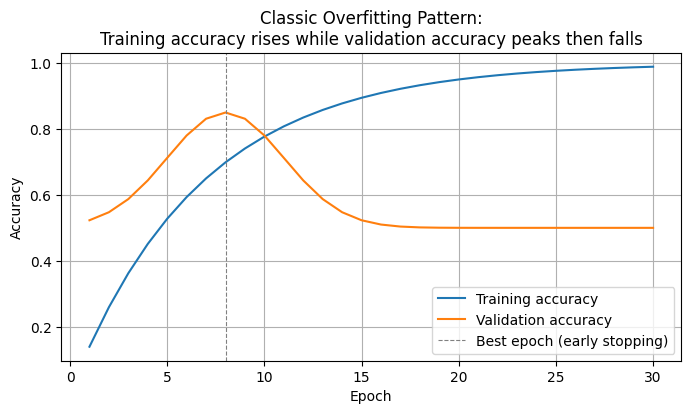

In [5]:
# Simulated overfitting curve — designed to show the classic pattern clearly
epochs = list(range(1, 31))

# Training accuracy: keeps climbing toward 1.0
train_acc = [1 - math.exp(-0.15 * e) for e in epochs]

# Validation accuracy: rises, peaks around epoch 8, then slowly falls
val_acc   = [0.5 + 0.35 * math.exp(-((e - 8)**2) / 18) for e in epochs]

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_acc, label='Training accuracy')
plt.plot(epochs, val_acc,   label='Validation accuracy')
plt.axvline(x=8, color='gray', linestyle='--', linewidth=0.8, label='Best epoch (early stopping)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Classic Overfitting Pattern:\nTraining accuracy rises while validation accuracy peaks then falls')
plt.legend()
plt.grid(True)
plt.show()

Look at the plot above showing training and validation accuracy over epochs.

Q: At which epoch does validation accuracy reach its highest value?

`YOUR ANSWER HERE`

Q: After that epoch, training accuracy continues to rise but validation accuracy falls. What does this tell you about how well the model generalizes to new data?

`YOUR ANSWER HERE`

Q: If you could save only one version of the model (one epoch's weights), which epoch
would you choose, and why?

`YOUR ANSWER HERE`


#### Underfitting

A model **underfits** when it hasn't learned enough from the training data.
Signs of underfitting:
- Training error is **high** (the model makes mistakes even on examples it was trained on)
- Test error is also **high** (it may be close to training error, and both are bad)

Underfitting often happens when:
- The model hasn't been trained for enough epochs (too few passes over the data)
- The training set is too small to convey the underlying pattern
- The model is too simple for the complexity of the task

#### Overfitting

A model **overfits** when it has learned the training examples *too specifically* — fitting
the noise or quirks of the training set rather than the underlying pattern.
Signs of overfitting:
- Training error is **low**
- Test error is **high** (much higher than training error)
- Training metric keeps improving with epochs, whereas validation metric improves, then gets worse

The goal is to find the "sweet spot" between underfitting and overfitting where both training
error and test error are low.


If training performance keeps improving but validation performance worsens, the model is overfitting.
This is the opposite of generalization: a model **generalizes** when what it learned on training data 
extends reliably to new, unseen examples drawn from the same distribution.

##### Some Ways We Can Reduce Overfitting

- **Use a validation set (early stopping)**  
  Monitor validation loss during training and stop when it begins to worsen.

- **Simplify the model**  
  Use fewer parameters (for example, fewer layers, fewer neurons, or a lower-degree model).

- **Add regularization**  
  Add a small penalty to discourage very large weights, encouraging smoother solutions.

- **Increase the training data**  
  More data makes it harder for the model to memorize noise.

- **Use data augmentation**  
  Create additional training examples by slightly modifying existing ones (for example, flipping or rotating images).

Let's load an example to help us see these concepts concretely.  This is an extension of the same toy data set from before.

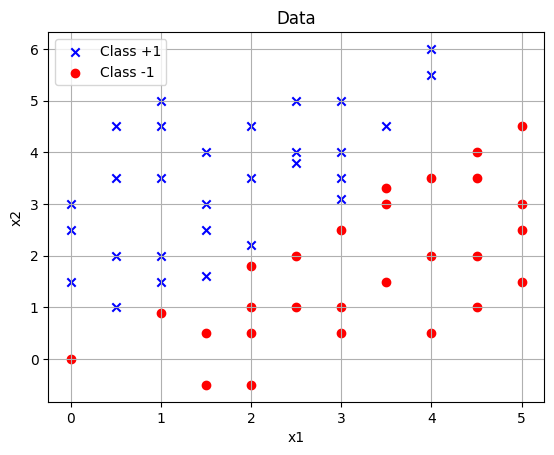

In [6]:

# Toy perceptron example, with more data!
# Each input is [x1, x2], label is +1 if x2 > x1, else -1

X_toy_bigger = [
    # --- Original points ---
    [1.5, 4.0],
    [1.0, 2.0],
    [2.0, 1.0],
    [3.0, 5.0],
    [4.0, 2.0],
    [0.0, 0.0],
    [1.5, -0.5],

    # --- Class +1 (x2 > x1) ---
    [0.5, 2.0],
    [1.0, 3.5],
    [2.0, 4.5],
    [0.0, 1.5],
    [3.0, 4.0],
    [1.5, 3.0],
    [2.5, 5.0],
    [0.5, 1.0],
    [4.0, 5.5],
    [1.0, 1.5],
    [3.5, 4.5],
    [0.0, 2.5],
    [2.0, 3.5],
    [1.5, 2.5],
    [0.5, 3.5],
    [3.0, 3.5],
    [2.5, 4.0],
    [1.0, 4.5],
    [0.0, 3.0],
    [1.0, 5.0],
    [2.5, 3.8],
    [0.5, 4.5],
    [4.0, 6.0],

    # --- Class -1 (x2 <= x1) ---
    [3.0, 1.0],
    [4.5, 2.0],
    [2.0, 0.5],
    [5.0, 3.0],
    [3.5, 1.5],
    [4.0, 0.5],
    [2.5, 1.0],
    [5.0, 4.5],
    [4.5, 3.5],
    [3.0, 2.5],
    [1.5, 0.5],
    [2.5, 2.0],
    [4.0, 3.5],
    [3.5, 3.0],
    [5.0, 1.5],
    [5.0, 2.5],
    [4.5, 1.0],
    [3.0, 0.5],
    [2.0, -0.5],
    [4.5, 4.0],

    # --- Noisy points near x2 ≈ x1 ---
    [2.0, 2.2],
    [3.0, 3.1],
    [1.5, 1.6],
    [2.0, 1.8],
    [3.5, 3.3],
    [1.0, 0.9],
]

y_toy_bigger = [
    # Original
    1, 1, -1, 1, -1, -1, -1,
    # Class +1
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    # Class -1
    -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
    # Noisy
    1, 1, 1, -1, -1, -1,
]

# Separate points by class for coloring
def plot_points(X_points, y_labels):
    X_pos = [x for x, y in zip(X_points, y_labels) if y == 1]
    X_neg = [x for x, y in zip(X_points, y_labels) if y == -1]

    plt.scatter([x[0] for x in X_pos], [x[1] for x in X_pos], color='blue', marker='x', label='Class +1')
    plt.scatter([x[0] for x in X_neg], [x[1] for x in X_neg], color='red', marker='o',  label='Class -1')

    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title('Data')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_points(X_toy_bigger, y_toy_bigger)

### Training Curve vs. Learning Curve

**Training Curve** — plots error or other metric on the *training set* as a function of steps / epochs or training set size.
- A very low training error sounds good, but alone it tells us nothing about generalization.

**Learning Curve** — plots *both* training and test (or validation) error as training set size grows.
- As training size increases, we expect:
  - Training error to **rise slightly** (harder to perfectly fit more data)
  - Test error to **fall** (model sees more of the true distribution)
- When the two curves **converge at a low error**, the model is generalizing well.
- When training error is low but test error stays high, the model is **overfitting**.

Before we explore how the error rate of the perceptron changes throughout the training and validation, we need to consider how to split the data set.

#### Implementing train/test split

1. **Randomize the data:**
    We shuffle the dataset so that the order does not affect which points end up in the training or testing sets. This helps ensure that both sets are representative of the overall data.

2. **Split into training and testing sets:** After shuffling, we divide the data into two parts:
    - The **training set** is used to fit (train) the model.  
    - The **testing set** is used to evaluate the model's performance on unseen data.

3. **Apply the split to both inputs and outputs:**  
    We split both the input values and the corresponding output values in the same way, so each input still matches its correct output.

This process helps us measure how well our model is likely to perform on new, real-world data, not just the data it was trained on.

In [7]:
# Use type hints for function parameter and return type
from typing import List, Sequence, Tuple 

def train_test_split_v1(
    X: Sequence[Sequence[float]],
    y: Sequence[int],
    test_ratio: float = 0.2,
    seed: int = 0,
    shuffle: bool = True,
) -> Tuple[List[List[float]], List[List[float]], List[int], List[int]]:
    '''
    Split a dataset into training and test subsets.

    Optionally shuffles the data before splitting so that the test set is
    a random sample rather than always the last `test_ratio` fraction of
    the original order.
    
    X: list of input features
    y: list of target labels
    test_ratio: fraction of the data to put in the test set. Must be between 0 and 1. Default is 0.2 (20%).
    seed: Random seed used for shuffling, so results are reproducible. Default is 0.
    shuffle: If True, randomly shuffle the data before splitting.
            If False, take the first (1 - test_ratio) fraction for training and the rest for testing. Default is True.
    '''
    indices = list(range(len(y)))

    if shuffle:
        # Create a local instance random number generator to randomly shuffle
        rng = random.Random(seed)
        rng.shuffle(indices)

    n_test = max(1, round(len(y) * test_ratio))
    test_indices  = indices[:n_test]
    train_indices = indices[n_test:]

    X_list = [list(row) for row in X]
    y_list = [int(v)    for v in y]

    return (
        [X_list[i] for i in train_indices],
        [X_list[i] for i in test_indices],
        [y_list[i] for i in train_indices],
        [y_list[i] for i in test_indices],
    )

Q: Why did we shuffle the indices first, and not the lists directly?

`YOUR ANSWER HERE`

In [8]:
X_train, X_test, y_train, y_test = train_test_split_v1(X_toy_bigger, y_toy_bigger, test_ratio=0.2, seed=42)

def class_counts(y, split_name):
    '''
    Count the number of positive and negative labeled data points in a data set

    y: list of labels
    split_name: descriptive string for which list of labels is being used
    '''
    pos = y.count(1)
    neg = y.count(-1)
    total = len(y)
    print(f"{split_name} ({total} points):")
    print(f"  Class +1: {pos}  ({100*pos/total:.1f}%)")
    print(f"  Class -1: {neg}  ({100*neg/total:.1f}%)")

class_counts(y_toy_bigger,   "Full dataset")
class_counts(y_train, "Train set   ")
class_counts(y_test,  "Test set    ")

Full dataset (56 points):
  Class +1: 29  (51.8%)
  Class -1: 27  (48.2%)
Train set    (45 points):
  Class +1: 21  (46.7%)
  Class -1: 24  (53.3%)
Test set     (11 points):
  Class +1: 8  (72.7%)
  Class -1: 3  (27.3%)


How much does class balance vary across random splits?

In [9]:
# How much does class balance vary across random splits (no stratification)?
print("Seed | Test +1 | Test -1 | Train +1 | Train -1")
print("-" * 50)
for seed in range(20):
    X_tr, X_te, y_tr, y_te = train_test_split_v1(X_toy_bigger, y_toy_bigger, test_ratio=0.2, seed=seed)
    print(
        f"  {seed:2d} |"
        f"   {y_te.count(1):3d}   |"
        f"   {y_te.count(-1):3d}   |"
        f"    {y_tr.count(1):3d}   |"
        f"    {y_tr.count(-1):3d}"
    )

print()
print(f"Full dataset: +1={y_toy_bigger.count(1)}, -1={y_toy_bigger.count(-1)}")
print(f"Ideal test set (20%): +1≈{round(y_toy_bigger.count(1)*0.2)}, -1≈{round(y_toy_bigger.count(-1)*0.2)}")

Seed | Test +1 | Test -1 | Train +1 | Train -1
--------------------------------------------------
   0 |     5   |     6   |     24   |     21
   1 |     4   |     7   |     25   |     20
   2 |     8   |     3   |     21   |     24
   3 |     9   |     2   |     20   |     25
   4 |     7   |     4   |     22   |     23
   5 |     4   |     7   |     25   |     20
   6 |     4   |     7   |     25   |     20
   7 |     6   |     5   |     23   |     22
   8 |     7   |     4   |     22   |     23
   9 |     5   |     6   |     24   |     21
  10 |     3   |     8   |     26   |     19
  11 |     5   |     6   |     24   |     21
  12 |     5   |     6   |     24   |     21
  13 |     5   |     6   |     24   |     21
  14 |     6   |     5   |     23   |     22
  15 |     6   |     5   |     23   |     22
  16 |     7   |     4   |     22   |     23
  17 |     1   |    10   |     28   |     17
  18 |     8   |     3   |     21   |     24
  19 |     3   |     8   |     26   |     19

F

Which seed do we trust? We shouldn't have to choose — that's what stratification fixes.

#### What is Stratification?

**Stratification** ensures that each split (train, test, or validation) contains
roughly the **same proportion of each class** as the full dataset.

For example, if the full dataset is 60% Class +1 and 40% Class -1,
a stratified split guarantees your train and test sets are also approximately
60/40 — regardless of the random seed used.

Without stratification, a random shuffle might accidentally concentrate
one class in the test set, making evaluation misleading.

In [10]:
def train_test_split_v2(
    X: Sequence[Sequence[float]],
    y: Sequence[int],
    test_ratio: float = 0.2,
    seed: int = 0,
    shuffle: bool = True,
) -> Tuple[List[List[float]], List[List[float]], List[int], List[int]]:
    '''
    Split data set with stratification: preserves class proportions in each split.

    X: list of input features
    y: list of target labels
    test_ratio: fraction of the data to put in the test set. Must be between 0 and 1. Default is 0.2 (20%).
    seed: Random seed used for shuffling, so results are reproducible. Default is 0.
    shuffle: If True, randomly shuffle the data before splitting.
            If False, take the first (1 - test_ratio) fraction for training and the rest for testing. Default is True.
    '''
    # Create a local instance random number generator, in case shuffle is True.
    rng = random.Random(seed)
    # Group indices by class label
    labels = list(set(y))
    class_indices = {label: [i for i, v in enumerate(y) if v == label] for label in labels}

    train_indices = []
    test_indices  = []

    for label in labels:
        idxs = class_indices[label][:]
        if shuffle:
            rng.shuffle(idxs)
        n_test = max(1, round(len(idxs) * test_ratio))
        test_indices  += idxs[:n_test]
        train_indices += idxs[n_test:]

    if shuffle:
        rng.shuffle(train_indices)
        rng.shuffle(test_indices)

    X_list = [list(row) for row in X]
    y_list = [int(v)    for v in y]

    return (
        [X_list[i] for i in train_indices],
        [X_list[i] for i in test_indices],
        [y_list[i] for i in train_indices],
        [y_list[i] for i in test_indices],
    )

In [11]:
print("       -v1 (no stratify)-    -v2 (stratified)-")
print("Seed | Test +1 | Test -1 | Test +1 | Test -1")
print("-" * 55)
for seed in range(20):
    _, _, _, y_te_v1 = train_test_split_v1(X_toy_bigger, y_toy_bigger, test_ratio=0.2, seed=seed)
    _, _, _, y_te_v2 = train_test_split_v2(X_toy_bigger, y_toy_bigger, test_ratio=0.2, seed=seed)
    print(
        f"  {seed:2d} |"
        f"   {y_te_v1.count(1):3d}   |"
        f"   {y_te_v1.count(-1):3d}   |"
        f"   {y_te_v2.count(1):3d}   |"
        f"   {y_te_v2.count(-1):3d}"
    )

print()
print(f"Full dataset: +1={y_toy_bigger.count(1)}, -1={y_toy_bigger.count(-1)}")
print(f"Ideal test set (20%): +1≈{round(y_toy_bigger.count(1)*0.2)}, -1≈{round(y_toy_bigger.count(-1)*0.2)}")

       -v1 (no stratify)-    -v2 (stratified)-
Seed | Test +1 | Test -1 | Test +1 | Test -1
-------------------------------------------------------
   0 |     5   |     6   |     6   |     5
   1 |     4   |     7   |     6   |     5
   2 |     8   |     3   |     6   |     5
   3 |     9   |     2   |     6   |     5
   4 |     7   |     4   |     6   |     5
   5 |     4   |     7   |     6   |     5
   6 |     4   |     7   |     6   |     5
   7 |     6   |     5   |     6   |     5
   8 |     7   |     4   |     6   |     5
   9 |     5   |     6   |     6   |     5
  10 |     3   |     8   |     6   |     5
  11 |     5   |     6   |     6   |     5
  12 |     5   |     6   |     6   |     5
  13 |     5   |     6   |     6   |     5
  14 |     6   |     5   |     6   |     5
  15 |     6   |     5   |     6   |     5
  16 |     7   |     4   |     6   |     5
  17 |     1   |    10   |     6   |     5
  18 |     8   |     3   |     6   |     5
  19 |     3   |     8   |     6   

Now that we have a reliable split, we'll use the bigger toy dataset to explore three
questions about how a model learns:

1. **Training curve** — how does training and test error change epoch by epoch?
   *(Answer: training error falls quickly; the gap between train and test error shows
   how well the model generalizes to new data.)*

2. **Learning curve** — how does test error change as we increase the training set size?
   *(Answer: more data gives lower test error and smaller gap between train and test.)*

3. **Decision boundary comparison** — what does the *shape* of the learned boundary
   look like for a tiny vs. large training set?
   *(Answer: with little data, the boundary may fit the few points it saw but miss
   the true underlying pattern.)*

We'll train the perceptron on two different versions of the same dataset:
- A **tiny training set** (only 15% of the data) — the model has very little to learn from.
- A **larger training set** (80% of the data) — the model has much more information.

In [12]:
def perceptron_train_eval_with_history(X, y, num_epochs=10,X_test=None, y_test=None):
    '''
    Train a perceptron and record loss, accuracy, precision, and recall
    after every individual data point is processed (across all epochs).

    X: list of [x1, x2] feature pairs
    y: list of labels in {-1, +1}
    num_epochs: number of full passes over the data
    X_test, y_test: optional test sets for calculating test accuracty

    Returns
    w, b : final weights and bias
    history : dictionary with keys 'loss', 'accuracy', 'precision', 'recall',
              each a list of length (num_epochs * len(X)). Also has a key 'test_accuracy' (one value per epoch) if X_test is provided.
    '''
    w = [0.0, 0.0]
    b = 0.0

    history = {'loss': [], 'accuracy': [], 'precision': [], 'recall': [], 'test_accuracy': []}

    rng = random.Random(42)

    for epoch in range(num_epochs):
        # Shuffle a new order each epoch
        combined = list(zip(X, y))
        rng.shuffle(combined)

        for x, y_true in combined:
            # Calculate perceptron score and apply update rule
            score  = w[0] * x[0] + w[1] * x[1] + b
            y_pred = 1 if score >= 0 else -1

            if y_pred != y_true:
                w[0] += y_true * x[0]
                w[1] += y_true * x[1]
                b    += y_true

            # Calculate current model predictions for all training data
            all_preds = perceptron_predict_all(X, w, b)

            # Total perceptron loss = sum of max(0, -y*z) across all points
            total_loss = sum(
                max(0.0, -yt * (w[0]*xt[0] + w[1]*xt[1] + b))
                for xt, yt in zip(X, y)
            )

            acc, prec, rec = compute_metrics(y, all_preds)

            history['loss'].append(total_loss)
            history['accuracy'].append(acc)
            history['precision'].append(prec)
            history['recall'].append(rec)

        # Record test accuracy once per epoch
        if X_test is not None and y_test is not None:
            test_preds = perceptron_predict_all(X_test, w, b)
            test_acc, _, _ = compute_metrics(y_test, test_preds)
            history['test_accuracy'].append(test_acc)

        if history['accuracy'][-1] == 1.0: break

    return w, b, history

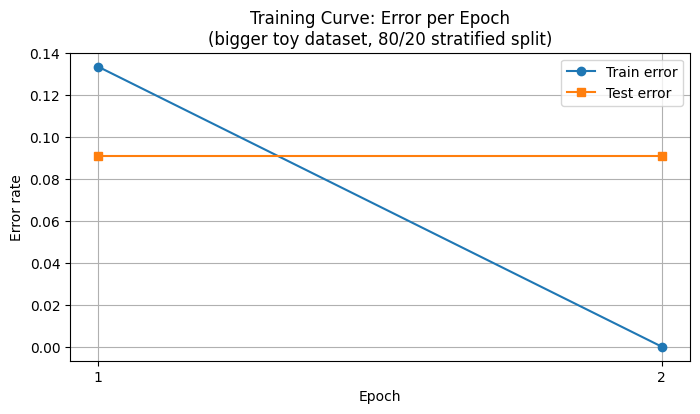

In [13]:
# Training curve: how model error changes as training progresses (epoch by epoch)
X_train, X_test, y_train, y_test = train_test_split_v2(
    X_toy_bigger, y_toy_bigger, test_ratio=0.2, seed=42
)

w, b, history = perceptron_train_eval_with_history(
    X_train, y_train, num_epochs=20,
    X_test=X_test, y_test=y_test
)

n_pts = len(X_train)
num_epochs_run = len(history['test_accuracy'])

# Sample epoch-end values from the per-point history
epoch_train_err = [1.0 - history['accuracy'][n_pts*(e+1)-1] for e in range(num_epochs_run)]
epoch_test_err  = [1.0 - a for a in history['test_accuracy']]

epochs = list(range(1, num_epochs_run + 1))
plt.figure(figsize=(8, 4))
plt.plot(epochs, epoch_train_err, marker='o', label='Train error')
plt.plot(epochs, epoch_test_err,  marker='s', label='Test error')
plt.xlabel('Epoch')
plt.xticks([1, 2])
plt.ylabel('Error rate')
plt.title('Training Curve: Error per Epoch\n(bigger toy dataset, 80/20 stratified split)')
plt.legend()
plt.grid(True)
plt.show()

   #### Some observations about the curves:

   
- **Early stopping of training**
    - At epoch 1 the model has completed one full pass over the training data but hasn't yet classified all points correctly. It makes about 6 errors on ~44 training points (≈13.6%).
    - The perceptron reaches zero training error by the end of epoch 2 and stops. 
    - The x-axis only goes to 2 even though `num_epochs=20` was requested.
- **Test error is flat**
    - Test error is the same at epoch 1 and at epoch 2, despite train error decreasing.
    - The test set has ~11 points (20% of ~55). At epoch 1, the boundary already correctly classifies 10 of those 11 test points. At epoch 2, even though the boundary shifts enough to fix all remaining training errors, the one misclassified test point stays on the wrong side. The boundary adjustment helped training but did not change how the test point was classified.
    - Fitting the training data perfectly does not guarantee better generalization. The model has converged to a valid separating hyperplane for the training data but not the one that happens to classify this particular test set perfectly.
    - The 9% persistent test error tells us something real: the model has learned a boundary that generalizes imperfectly, and no amount of additional training epochs will fix it. The only remedy is more *training data* or a different hyperparameter (e.g. initialization of random seed).
- **How can train error be higher than test error?**
   - Normally we expect train error to be less than or equal to test error, since the model was trained on those points, so it should "know" them better.
   - The 20-point test set contains 11 relatively easy-to-classify points (they may lie far from the true boundary). On the other hand, the 44 training points include some near the boundary that the model keeps getting wrong during the first epoch. By the end of epoch 1 the model has mostly converged but a few boundary-adjacent training points are still misclassified — while all test points happen to already be on the right side of the partially-trained boundary.
   - Low test error early on does not mean the model is "good". Rather, it means this particular train/test split produced a test set that was easier than average. This is exactly the kind of accident that **stratification helps prevent** for class balance, but cannot prevent for "easy vs. hard" cases.


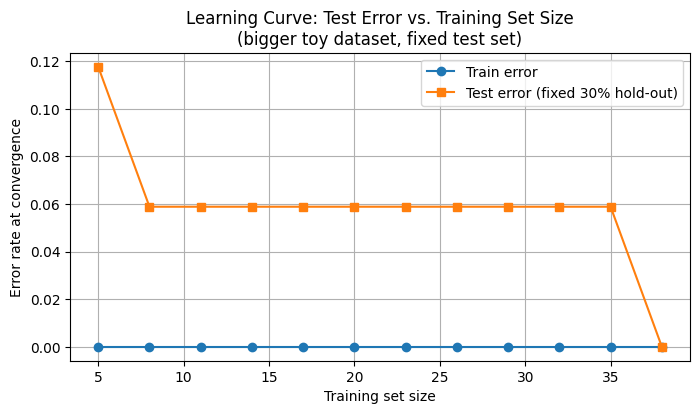

In [14]:
# Learning curve: how test error changes as we give the model more training data
# Fixed test set, grow only the training subset

# Reserve a fixed 30% as the test set — this never changes.
X_train_pool, X_test_fixed, y_train_pool, y_test_fixed = train_test_split_v2(
    X_toy_bigger, y_toy_bigger, test_ratio=0.30, seed=42
)

# Sweep over growing subsets of the training pool.
# Use train_test_split_v2 for each size so that class balance is preserved
# at every training set size (stratified subsampling).
min_train = 5
max_train = len(X_train_pool)
step      = 3

all_sizes  = list(range(min_train, max_train + 1, step))
train_errs = []
test_errs  = []

for n_train in all_sizes:
    if n_train >= len(X_train_pool):
        # Use the entire training pool
        X_tr, y_tr = X_train_pool, y_train_pool
    else:
        # Stratified subsample: take n_train points from the pool,
        # preserving the positive/negative class ratio.
        discard_ratio = 1.0 - n_train / len(X_train_pool)
        X_tr, _, y_tr, _ = train_test_split_v2(
            X_train_pool, y_train_pool,
            test_ratio=discard_ratio,
            seed=42
        )

    w_lc, b_lc, hist_lc = perceptron_train_with_history(X_tr, y_tr, num_epochs=50)

    # Training error at convergence
    train_err = 1.0 - hist_lc['accuracy'][-1]

    # Test error on the FIXED test set (same 30% every time)
    test_preds = perceptron_predict_all(X_test_fixed, w_lc, b_lc)
    test_acc, _, _ = compute_metrics(y_test_fixed, test_preds)
    test_err = 1.0 - test_acc

    train_errs.append(train_err)
    test_errs.append(test_err)

plt.figure(figsize=(8, 4))
plt.plot(all_sizes, train_errs, marker='o', label='Train error')
plt.plot(all_sizes, test_errs,  marker='s', label='Test error (fixed 30% hold-out)')
plt.xlabel('Training set size')
plt.ylabel('Error rate at convergence')
plt.title('Learning Curve: Test Error vs. Training Set Size\n(bigger toy dataset, fixed test set)')
plt.legend()
plt.grid(True)
plt.show()

#### Some observations about the curves:

- **Very low training error**
    - Training error stays near 0 for all training set sizes
    - The perceptron always converges to zero train error on linearly separable data.
- **Generalization improves with larger training set size**
    - Test error starts high when the training set is tiny
    - Few training points likely means poor generalization
    - Test error monotonically decreases as more training data is provided
    - The gap between the train error and test error curves is the "generalization gap". It is large when the training set is small, shrinking toward zero as training size grows.

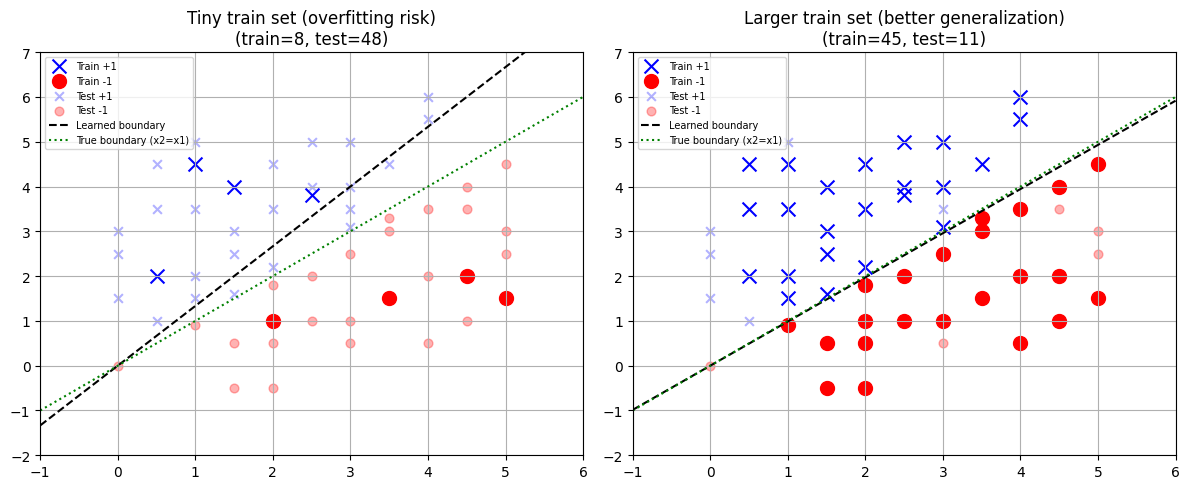

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, ratio, title in zip(
    axes,
    [0.85, 0.20],
    ["Tiny train set (overfitting risk)", "Larger train set (better generalization)"]
):
    X_tr, X_te, y_tr, y_te = train_test_split_v2(X_toy_bigger, y_toy_bigger, test_ratio=ratio, seed=42)
    w, b, _ = perceptron_train_with_history(X_tr, y_tr, num_epochs=20)

    # Plot all points, highlighting which were in training
    X_pos_tr = [x for x, y in zip(X_tr, y_tr) if y ==  1]
    X_neg_tr = [x for x, y in zip(X_tr, y_tr) if y == -1]
    X_pos_te = [x for x, y in zip(X_te, y_te) if y ==  1]
    X_neg_te = [x for x, y in zip(X_te, y_te) if y == -1]

    ax.scatter([x[0] for x in X_pos_tr], [x[1] for x in X_pos_tr], color='blue',  marker='x', s=100, label='Train +1')
    ax.scatter([x[0] for x in X_neg_tr], [x[1] for x in X_neg_tr], color='red',   marker='o', s=100, label='Train -1')
    ax.scatter([x[0] for x in X_pos_te], [x[1] for x in X_pos_te], color='blue',  marker='x', s=40, alpha=0.3, label='Test +1')
    ax.scatter([x[0] for x in X_neg_te], [x[1] for x in X_neg_te], color='red',   marker='o', s=40, alpha=0.3, label='Test -1')

    import numpy as np
    x1_vals = np.linspace(-1, 6, 100)
    if w[1] != 0:
        x2_vals = -(w[0] * x1_vals + b) / w[1]
        ax.plot(x1_vals, x2_vals, 'k--', label='Learned boundary')

    # True boundary for reference
    ax.plot(x1_vals, x1_vals, 'g:', label='True boundary (x2=x1)')
    ax.set_xlim(-1, 6)
    ax.set_ylim(-2, 7)
    ax.set_title(f"{title}\n(train={len(X_tr)}, test={len(X_te)})")
    ax.legend(fontsize=7)
    ax.grid(True)

plt.tight_layout()
plt.show()